# Task1 - Environment Setup & Data Loading

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Load csv files into pandas dataframes
drivers = pd.read_csv("data/drivers.csv")
races = pd.read_csv("data/races.csv")
results = pd.read_csv("data/results.csv")
constructors = pd.read_csv("data/constructors.csv")
circuits = pd.read_csv("data/circuits.csv")

dataframes = {
    "drivers": drivers,
    "races": races,
    "results": results,
    "constructors": constructors,
    "circuits": circuits
}


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")

DRIVERS
Shape: (861, 9)

Data Types:
driverId       int64
driverRef        str
number           str
code             str
forename         str
surname          str
dob              str
nationality      str
url              str
dtype: object


RACES
Shape: (1125, 18)

Data Types:
raceId         int64
year           int64
round          int64
circuitId      int64
name             str
date             str
time             str
url              str
fp1_date         str
fp1_time         str
fp2_date         str
fp2_time         str
fp3_date         str
fp3_time         str
quali_date       str
quali_time       str
sprint_date      str
sprint_time      str
dtype: object


RESULTS
Shape: (26759, 18)

Data Types:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps             

# Task2 - Data Cleaning

In [107]:
# --- 1. results.csv ---
results_cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print("=== results.csv ===")
print(f"Total rows: {len(results)}\n")

for col in results_cols:
    n_missing = (results[col].astype(str) == '\\N').sum()
    pct = n_missing / len(results) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")

before = pd.DataFrame({
    "Before": results[results_cols].isna().sum()
})
results.head(15)

# --- 2. drivers.csv ---
drivers_cols = ['dob', 'nationality']

print("\n=== drivers.csv ===")
print(f"Total rows: {len(drivers)}\n")

for col in drivers_cols:
    n_missing = (drivers[col].astype(str) == '\\N').sum()
    pct = n_missing / len(drivers) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")


=== results.csv ===
Total rows: 26759

milliseconds: 19079 missing (71.30%)
fastestLapTime: 18507 missing (69.16%)
fastestLapSpeed: 18507 missing (69.16%)

=== drivers.csv ===
Total rows: 861

dob: 0 missing (0.00%)
nationality: 0 missing (0.00%)


### additional note - why results.csv has so many missing values?

#### 1. a lack of record from the past

In [108]:
# Merge to bring in the 'year' column
results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# Split into pre-2000s and post-2000s (2000 onward)
pre_2000 = results[results['year'] < 2000]
post_2000 = results[results['year'] >= 2000]

def missing_pct(df, col):
    n_missing = (df[col].astype(str) == '\\N').sum()
    return n_missing / len(df) * 100

cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print(f"Pre-2000 rows: {len(pre_2000)}")
print(f"Post-2000 rows: {len(post_2000)}\n")

print(f"{'Column':<18}{'Pre-2000 missing %':<22}{'Post-2000 missing %'}")
for col in cols:
    pre_pct = missing_pct(pre_2000, col)
    post_pct = missing_pct(post_2000, col)
    print(f"{col:<18}{pre_pct:<22.2f}{post_pct:.2f}")


Pre-2000 rows: 16680
Post-2000 rows: 10079

Column            Pre-2000 missing %    Post-2000 missing %
milliseconds      82.15                 53.34
fastestLapTime    100.00                18.13
fastestLapSpeed   100.00                18.13


#### 2. a result of DNF

In [109]:
cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

for col in cols:
    missing_mask = results[col].astype(str) == '\\N'
    n_missing = missing_mask.sum()
    
    # Among the missing rows, how many are DNF (positionText == 'R')?
    n_dnf_in_missing = (results.loc[missing_mask, 'positionText'] == 'R').sum()
    dnf_ratio = n_dnf_in_missing / n_missing * 100 if n_missing > 0 else 0
    
    print(f"=== {col} ===")
    print(f"Total missing: {n_missing}")
    print(f"Missing rows that are DNF (positionText == 'R'): {n_dnf_in_missing}")
    print(f"DNF ratio among missing: {dnf_ratio:.2f}%\n")

=== milliseconds ===
Total missing: 19079
Missing rows that are DNF (positionText == 'R'): 8897
DNF ratio among missing: 46.63%

=== fastestLapTime ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%

=== fastestLapSpeed ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%



As you can see, the missing values in results.csv are highly influenced by lack of record before 2000. And high ratio of DNF caused a lot of missing values as well.


# Task3 - Merge Master Dataset

In [110]:
# Build driver full name
drivers['driverName'] = drivers['forename'] + ' ' + drivers['surname']

race_cols = ['raceId', 'round']
merged = results.merge(races[race_cols], on='raceId', how='left')

# Merge in driver names
merged = merged.merge(drivers[['driverId', 'driverName']], on='driverId', how='left')

# Merge in constructor names
merged = merged.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructorName'}),
    on='constructorId', how='left'
)

# Select the required columns
final_cols = [
    'raceId', 'year', 'round', 'driverName', 'constructorName',
    'grid', 'position', 'points', 'statusId'
]

merged_f1 = merged[final_cols]

print(merged_f1.shape)
print(merged_f1.head())

# Export to CSV
merged_f1.to_csv('jaeeun/output/merged_f1.csv', index=False)

(26759, 9)
   raceId  year  round         driverName constructorName  grid position  \
0      18  2008      1     Lewis Hamilton         McLaren     1        1   
1      18  2008      1      Nick Heidfeld      BMW Sauber     5        2   
2      18  2008      1       Nico Rosberg        Williams     7        3   
3      18  2008      1    Fernando Alonso         Renault    11        4   
4      18  2008      1  Heikki Kovalainen         McLaren     3        5   

   points  statusId  
0    10.0         1  
1     8.0         1  
2     6.0         1  
3     5.0         1  
4     4.0         1  


# Task4 - Top Drivers by Career Points

In [111]:
# If results already has year, avoid merging year again
if 'year' in results.columns:
    result_races = results.copy()
else:
    result_races = results.merge(
        races[['raceId', 'year']],
        on='raceId',
        how='left'
    )

result_races = result_races[
    (result_races["year"] >= 1995) &
    (result_races["year"] <= 2020)
]

career_points = result_races.groupby('driverId', as_index=False).agg(
    Total_Points=('points', 'sum')
)

career_points = career_points.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

career_points["driver"] = (
    career_points["forename"] + " " + career_points["surname"]
)

top10 = (
    career_points[["driver", "Total_Points"]]
    .sort_values("Total_Points", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10

,driver,Total_Points
0,Lewis Hamilton,3778.0
1,Sebastian Vettel,3018.0
2,Fernando Alonso,1899.0
3,Kimi Räikkönen,1863.0
4,Nico Rosberg,1594.5
5,Valtteri Bottas,1512.0
6,Michael Schumacher,1365.0
7,Jenson Button,1235.0
8,Felipe Massa,1167.0
9,Max Verstappen,1162.0


/var/folders/dr/v66_x2k55hbc5gf4xyt07q4h0000gn/T/ipykernel_28550/1625003183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


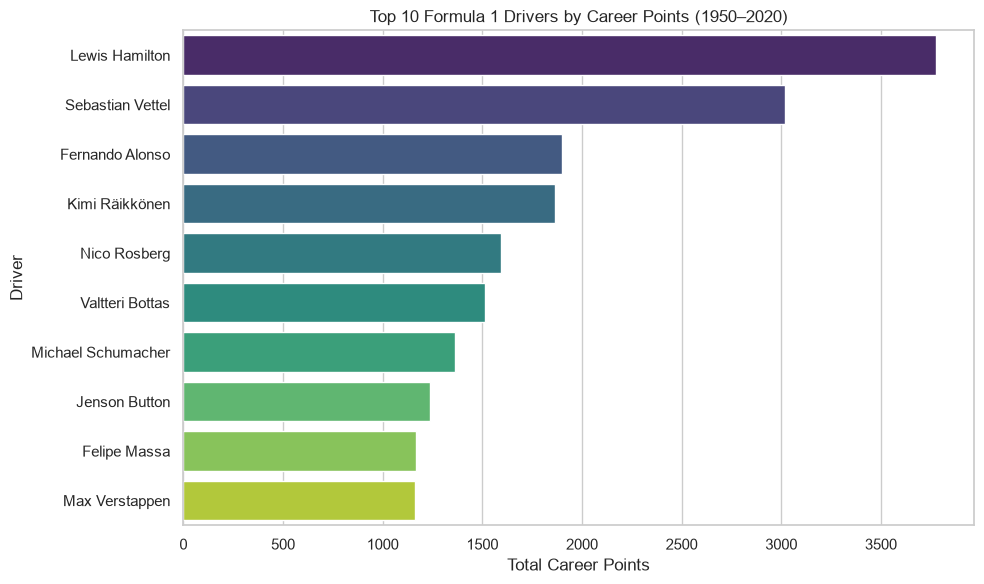

In [112]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="Total_Points",
    y="driver",
    palette="viridis"
)

plt.title("Top 10 Formula 1 Drivers by Career Points (1950–2020)")
plt.xlabel("Total Career Points")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

# Task5 - Top Constructors by Decade

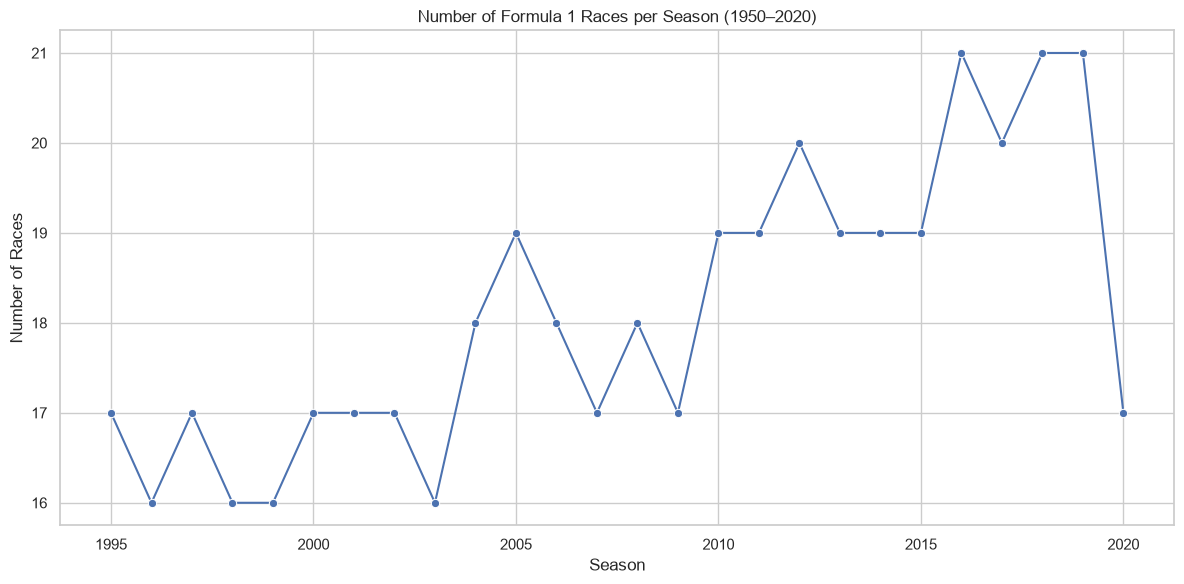

In [113]:
result_races = races[(races["year"] >= 1995) 
                            & (races["year"] <= 2020)]

result_races
num_of_races = (
    result_races
    .groupby("year")
    .size()
    .reset_index(name="num_of_races")    
)

sns.set_theme(style="whitegrid")

#graph drawing
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=num_of_races,
    x="year",
    y="num_of_races",
    marker="o"
)

plt.title("Number of Formula 1 Races per Season (1950–2020)")
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.tight_layout()

# saving as png
plt.savefig("chart1_races_per_season.png", dpi=300)

plt.show()

# Task6 - NumPy Statistics on Finishing Position

In [114]:
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors='coerce')

driver_names = ["Lewis Hamilton", "Michael Schumacher"]

selected = drivers.copy()
selected["driver"] = selected["forename"] + " " + selected["surname"]

selected = selected[selected["driver"].isin(driver_names)]
selected
hamilton_id = selected[selected["driver"]=="Lewis Hamilton"]["driverId"].iloc[0]
schumacher_id = selected[selected["driver"]=="Michael Schumacher"]["driverId"].iloc[0]

hamilton_pos = results.loc[
    results["driverId"] == hamilton_id,
    "positionOrder"
].to_numpy()

schumacher_pos = results.loc[
    results["driverId"] == schumacher_id,
    "positionOrder"
].to_numpy()
comparison = pd.DataFrame({
    "Driver": driver_names,
    "Mean Finish": [
        np.mean(hamilton_pos),
        np.mean(schumacher_pos)
    ],
    "Median Finish": [
        np.median(hamilton_pos),
        np.median(schumacher_pos)
    ],
    "Std Dev": [
        np.std(hamilton_pos),
        np.std(schumacher_pos)
    ]
})

comparison

,Driver,Mean Finish,Median Finish,Std Dev
0,Lewis Hamilton,5.019663,3.0,5.543207
1,Michael Schumacher,6.879870,3.0,7.061087


# Task7 - Chart 1 - Races per Season

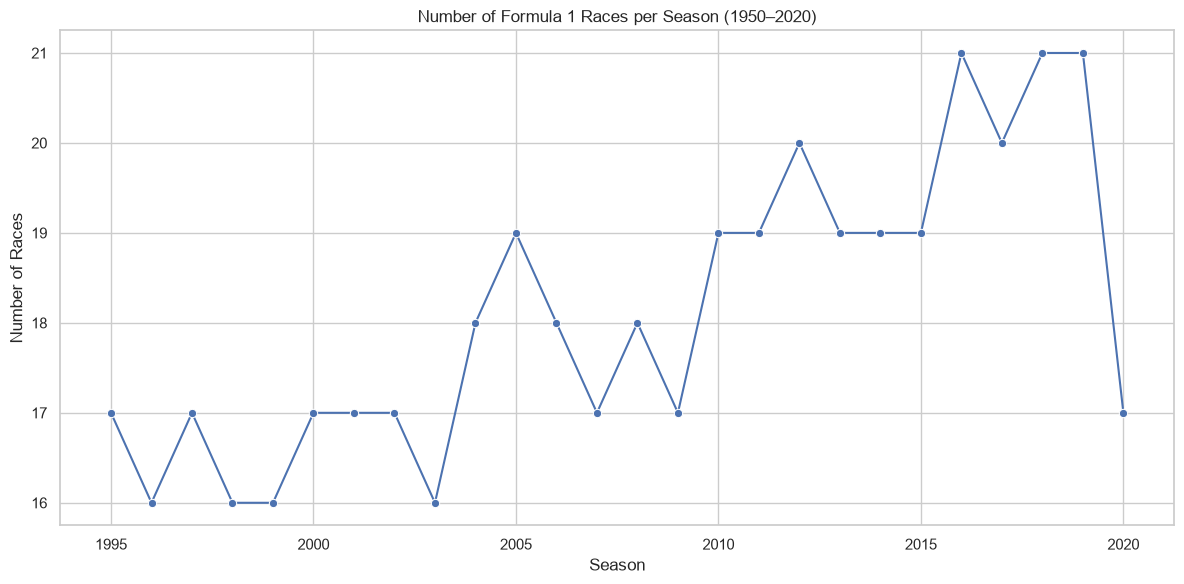

In [115]:
result_races = races[(races["year"] >= 1995) 
                            & (races["year"] <= 2020)]

result_races
num_of_races = (
    result_races
    .groupby("year")
    .size()
    .reset_index(name="num_of_races")    
)

num_of_races
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

#graph drawing
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=num_of_races,
    x="year",
    y="num_of_races",
    marker="o"
)

plt.title("Number of Formula 1 Races per Season (1950–2020)")
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.tight_layout()

# saving as png
plt.savefig("jaeeun/output/chart1_races_per_season.png", dpi=300)

plt.show()

# Task8 - Chart 2 - Top 10 Drivers by Wins

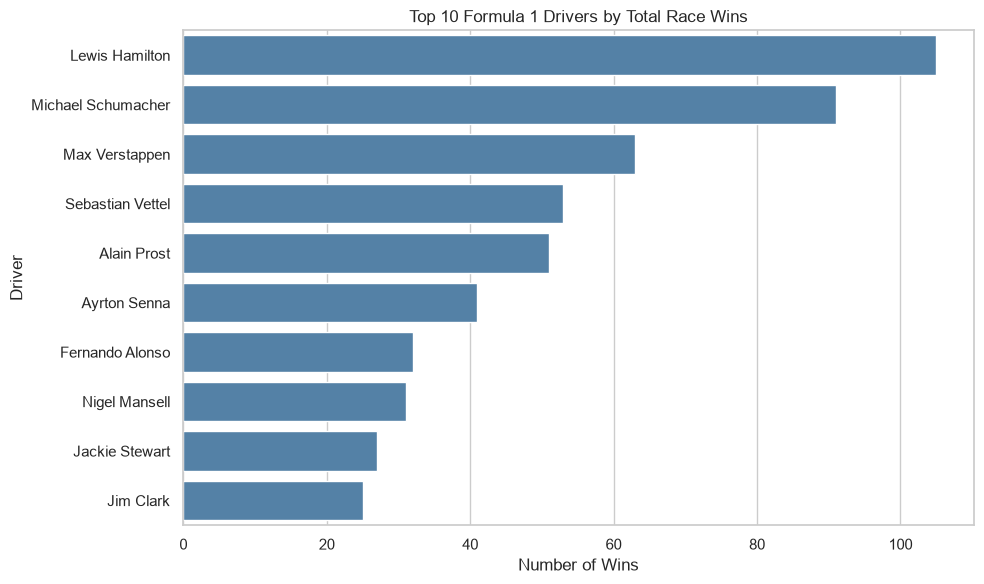

In [116]:
results_with_position = results.assign(
    position=pd.to_numeric(results["position"], errors="coerce")
)

wins_only = results_with_position[results_with_position["position"] == 1]

wins_by_driver = (
    wins_only
    .groupby("driverId")
    .size()
    .reset_index(name="wins")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId", how="left")
)

wins_by_driver["driver"] = (
    wins_by_driver["forename"] + " " + wins_by_driver["surname"]
)

top10_wins = (
    wins_by_driver[["driver", "wins"]]
    .sort_values("wins", ascending=False)
    .head(10)
    .reset_index(drop=True)
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_wins,
    x="wins",
    y="driver",
    color="steelblue",   # choose any color you like
)

plt.title("Top 10 Formula 1 Drivers by Total Race Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")
plt.tight_layout()
plt.savefig("jaeeun/output/chart2_top10_wins.png", dpi=300)
plt.show()

# Task9 - Chart 3 - Grid vs Finish Position

Correlation between starting grid position and final race position: 0.17


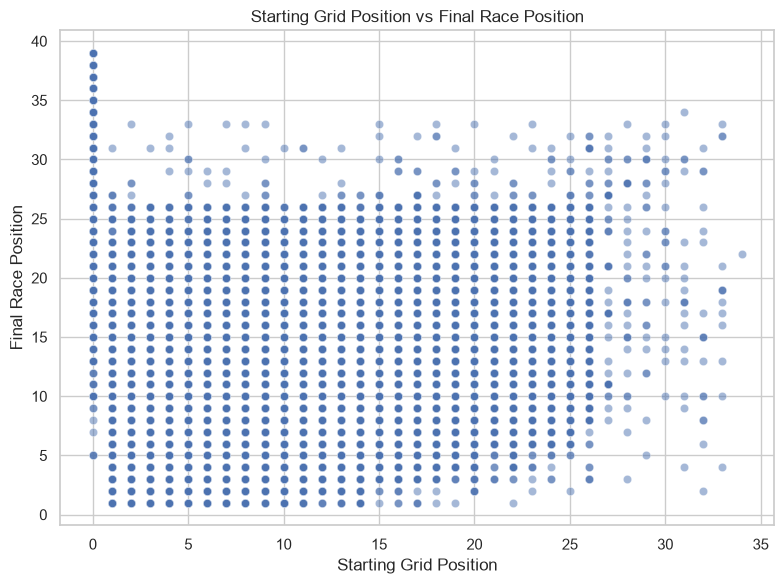

In [ ]:
#copying the relevant columns for plotting
plot_data = results[["grid", "positionOrder"]].copy()

plot_data["grid"] = pd.to_numeric(plot_data["grid"], errors="coerce")
plot_data["positionOrder"] = pd.to_numeric(
    plot_data["positionOrder"],
    errors="coerce"
)

plot_data = plot_data.dropna()

# Calculate the correlation coefficient between starting grid
correlation = np.corrcoef(
    plot_data["grid"],
    plot_data["positionOrder"]
)[0, 1]

# Display the correlation coefficient
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_data,
    x="grid",
    y="positionOrder",
    alpha=0.5
)

plt.title("Starting Grid Position vs Final Race Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Race Position")

plt.tight_layout()

plt.savefig("chart3_grid_vs_finish.png", dpi=300)

plt.show()

